In [1]:
import json

#results_file = 'benchmark_results_march_artificial_merged.json'
#results_file = 'benchmark_results_march_25_03.json'
results_file = 'benchmark_results_march.json'


with open(results_file, "r") as f:
            results = json.load(f)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
X = generate_gp_samples_with_library(4, 100, 3, np.linspace(0,1,30))

NameError: name 'generate_gp_samples_with_library' is not defined

In [14]:
X0, X1 = X[0], X[1]

In [59]:
from benchmarking_pred import Generate_samples, generate_gp_samples_with_library

X,y = Generate_samples(n_groups = 2, n_observations_per_group = 20)
#X1 = Generate_samples(n_groups = 1, n_observations_per_group = 100)

100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 281.11it/s]


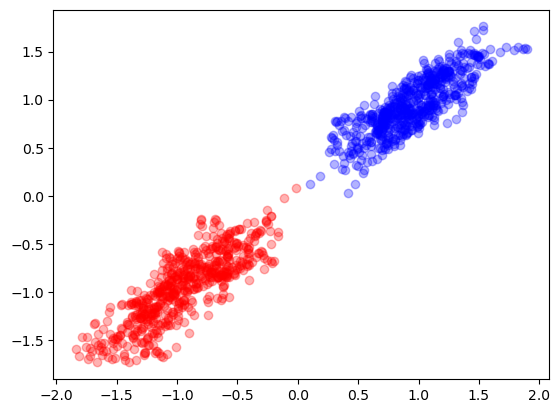

In [60]:
import matplotlib.pyplot as plt
for i in range(X.shape[0]):
    plt.scatter(X[i,:,0],X[i,:,1], c=c[int(y[i,0])], alpha = .3);
    #plt.scatter(X1[i,:,0],X1[i,:,1], c='b');

In [3]:
import json
import pandas as pd
import re
import numpy as np

def load_results_to_dataframe(json_path):
    with open(json_path, "r") as f:
        raw_results = json.load(f)

    rows = []
    for model_key, (metrics, training_time) in raw_results.items():
        row = {}

        # Parse model name and extract hyperparameters
        param_pattern = re.compile(
            r"(?P<method>GP_UAE|Posterior_consistency|KNN_Imputation|Mean_Imputation|MICE_Imputation)"
            r"(?:_(?P<p>[\d.]+))?"
            r"(?:_(?P<run>\d+))?"
            r"(?:_alpha_(?P<alpha>[\d.]+))?"
            r"(?:_sigma_(?P<sigma>[\d.]+))?"
            r"(?:_model_p_(?P<model_p>[\d.]+))?"
            r"(?:_detach_(?P<detach>True|False))?"
            r"(?:_DAE_(?P<DAE>True|False))?"
            r"(?:_pre_impute(?P<pre_impute>True|False))?"
        )

        match = param_pattern.match(model_key)
        if match:
            row.update(match.groupdict())
        else:
            print(f"⚠️ Could not parse key: {model_key}")

        # Flatten metric structure
        for section, section_data in metrics.items():
            for metric_name, value in section_data.items():
                row[f"{section}_{metric_name}"] = value if value is not None else np.nan

        # Add training time
        row["training_time"] = training_time

        # Add original key if needed
        row["model_key"] = model_key

        rows.append(row)

    df = pd.DataFrame(rows)
    return df

df = load_results_to_dataframe(results_file)
 
# Convert to floats if possible
for col in df.columns:
    try:
        df.loc[:,col] = df.loc[:,col].astype(float)
    except ValueError:
        continue

df.replace('False',False, inplace = True)
df.replace('True',True, inplace = True)

model_name_list = [x.split('_')  for x in df.model_key]
for x in model_name_list:
    x.pop(2) # delete 2nd element which corresponds to date missingness
    x.pop(2) # delete 4rd element which corresponds to run number

df['full_model_name'] = ['_'.join(x)  for x in model_name_list]
df = df[~ ((df.training_time < 30)&(df.training_time > 0.01))]

# change name of gp_UAE
df.loc[df.method == 'GP_UAE','method'] = 'UAE'


df.loc[df.method=='MICE_Imputation','method'] = 'Iterative_Imputer'

df['method_extended'] = df.method 
df.loc[(df.method == 'UAE')&(df.DAE),'method_extended'] = 'UAE_DAE'
df.loc[(df.method == 'UAE')&(df.pre_impute),'method_extended'] += '_pre_impute'

#df.loc[(df.method == 'UAE'),'method_extended'] += '_alpha_' + df.loc[(df.method == 'UAE'),'alpha'].astype(str)

# drop weird values of alpha for gpuae
        #mask = (df.alpha>= 0.1)&(df.alpha<=0.9)

# virer valeurs de lapha trop extremes pour gp uae
df_gp_uae = df.loc[(df.method == 'UAE')]
df_gp_uae = df_gp_uae[df_gp_uae.alpha.isin([0.1,0.8])]
df.loc[(df.method == 'UAE')] = df_gp_uae

df['hyper_param'] = None 
df.loc[df.method == 'UAE','hyper_param'] = 'alpha_' + df.loc[df.method == 'UAE','alpha'].astype(str)
df.loc[df.method == 'Posterior_consistency','hyper_param'] = 'lambda_' + df.loc[df.method == 'Posterior_consistency','alpha'].astype(str)

# ajout
df['lambda'] = df.alpha
df.loc[df.method != 'UAE','alpha'] = None
df.loc[df.method != 'Posterior_consistency','lambda'] = None

#df.fillna(0, inplace = True)
df.dropna(axis=0, how = 'all', inplace = True)
df.fillna(False, inplace = True)
df.loc[df.hyper_param==False,'hyper_param'] = 'None'


df.head()



,method,p,run,alpha,sigma,model_p,detach,DAE,pre_impute,observed_rmse,...,missing_uncertainty_error_corr,latent_latent_ks,latent_latent_log_prob,reconstruction_overall_coverage,training_time,model_key,full_model_name,method_extended,hyper_param,lambda
0,UAE,0.1,0.0,0.1,0.01,0.3,False,True,True,0.037922,...,0.131877,False,-0.195061,0.844222,71.517688,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.3_...,GP_UAE_alpha_0.1_sigma_0.01_model_p_0.3_detach...,UAE_DAE_pre_impute,alpha_0.1,False
1,UAE,0.1,0.0,0.1,0.01,0.3,False,True,False,0.040734,...,0.159760,False,-0.199190,0.842825,70.941045,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.3_...,GP_UAE_alpha_0.1_sigma_0.01_model_p_0.3_detach...,UAE_DAE,alpha_0.1,False
2,UAE,0.1,0.0,0.1,0.01,0.3,False,False,True,0.036874,...,0.630214,False,-0.194559,0.902032,131.653039,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.3_...,GP_UAE_alpha_0.1_sigma_0.01_model_p_0.3_detach...,UAE_pre_impute,alpha_0.1,False
3,UAE,0.1,0.0,0.1,0.01,0.3,False,False,False,0.038698,...,0.704063,False,-0.179814,0.912000,154.360401,GP_UAE_0.1_0_alpha_0.1_sigma_0.01_model_p_0.3_...,GP_UAE_alpha_0.1_sigma_0.01_model_p_0.3_detach...,UAE,alpha_0.1,False
4,UAE,0.1,0.0,0.8,0.01,0.3,False,True,True,0.033597,...,0.272715,False,-0.171025,0.885460,170.882137,GP_UAE_0.1_0_alpha_0.8_sigma_0.01_model_p_0.3_...,GP_UAE_alpha_0.8_sigma_0.01_model_p_0.3_detach...,UAE_DAE_pre_impute,alpha_0.8,False


In [4]:
df.groupby('run').count().iloc[:,0]

run
0.0    9
Name: method, dtype: int64

In [75]:
# for now use only first run
#df = df[(df.run==2) or (df.run==1)]
# tej les DAE
#df = df[~(df.DAE==True)]
df = df[(df.DAE==False)]
#df = df[(df.alpha!=0.8)&(df['lambda']!=0.1)&(df['lambda']!=0.01)]
#df = df[df.hyper_param.isin(['alpha_0.1','lambda_1.0'])]

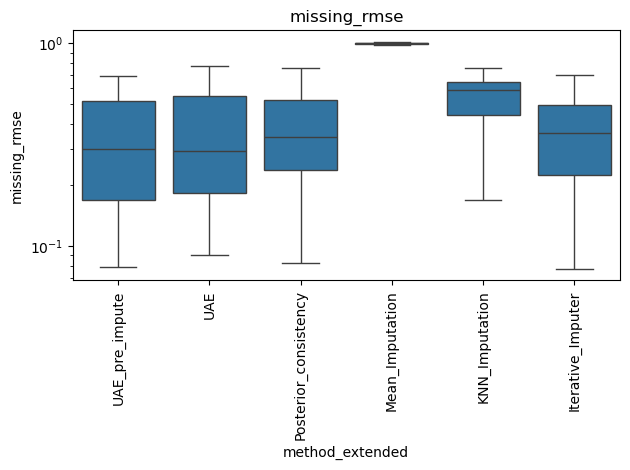

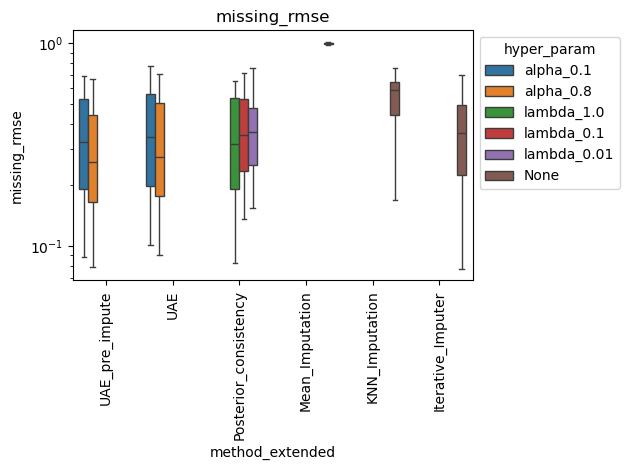

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['observed_rmse','missing_rmse',
           'observed_coverage', 'missing_coverage', 
           'latent_latent_log_prob', 'training_time',
           'observed_uncertainty_error_corr', 'missing_uncertainty_error_corr']

#metrics = ['observed_coverage', 'missing_coverage','observed_uncertainty_error_corr', 'missing_uncertainty_error_corr']
metrics = ['missing_rmse']

hues = [None, 'hyper_param'] #,'detach','DAE','pre_impute'] ,'sigma','model_p' 'alpha','lambda', , 'p'


mask_dict = {} #'p':0.1

for i,metric in enumerate(metrics):
    
    for hue in hues:

        fig_name = f'metric_{metric}_hue_{hue}' #metric_{metric}_
        title = f'{metric}'
        #plt.figure(figsize=(10,6))

        mask = (df.p == df.p) # True everywhere
        for key in mask_dict.keys():
            mask = mask & (df[key] == mask_dict[key])
            fig_name = fig_name + f'_mask_{key}_{mask_dict[key]}'
            title += f' for {key} = {mask_dict[key]}'

        #fig_name += '_all_alphas_'
        #fig_name += '_best_hyperparams'
        #title += ' for best hyperparameter choices'

        if metric not in ['missing_rmse']:
            mask = mask & (df.method.isin(['UAE','Posterior_consistency']))

        ax = sns.boxplot(df[mask],
                    x = 'method_extended',
                    y = metric,
                    hue = hue)
        try:
            sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
        except ValueError:
            pass


        if metric != 'latent_latent_log_prob':
            plt.yscale('log')
        plt.xticks(rotation=90);
        plt.title(title)
        plt.tight_layout();
        #fig.legend(bbox_to_anchor=[0.5, 0.5], loc='center right')

        plt.savefig('benchmark_UAE_plots_25_05_extensive/' + fig_name + '.png')
        plt.show()
        plt.close()